## Samuel Christopher - Credit Score Classification

## a. EDA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('Credis_Score_Dataset_B.csv')

In [4]:
df.shape

(50000, 28)

In [5]:
df.head(10)

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0xc765,CUS_0xade3,April,Kevin Limx,49,#F%$D@*&8,Entrepreneur,165076.44,NaN,1,...,Good,712.94,29.051769,18 Years and 2 Months,No,273.174717,1130.5113527934434,Low_spent_Large_value_payments,248.55092985209012,Standard
1,0x1fbf9,CUS_0x7651,April,Slaterv,40,300-72-2019,Manager,57321.36,4666.780000,10,...,Bad,2224.09,27.436038,NaN,Yes,420.888678,68.80243048143443,High_spent_Medium_value_payments,226.9868910810159,Standard
2,0x15891,CUS_0x84fe,April,Leee,38,579-44-7984,_______,30111.3,NaN,7,...,Bad,3075.29,38.259660,4 Years and 2 Months,Yes,140.836626,__10000__,High_spent_Small_value_payments,257.0932938020279,Poor
3,0x3ee7,CUS_0x7620,June,Fionag,24,#F%$D@*&8,Developer,36496.38_,2934.365000,8,...,Standard,1328.69,36.750990,NaN,Yes,45.812349,NaN,High_spent_Medium_value_payments,390.7583756600934,Poor
4,0x1e5aa,CUS_0x5572,May,Hyunjoo Jina,39,972-53-4211,Scientist,10068.97,NaN,8,...,Standard,2192.93,28.617576,15 Years and 1 Months,NM,23.222251,46.55878243363996,Low_spent_Medium_value_payments,294.2270494281999,Standard
5,0x1eef5,CUS_0x64e5,August,Dinesh Nairu,34,692-52-3599,Teacher,21803.94,1782.995000,5,...,Standard,29.16,33.799756,31 Years and 2 Months,No,41.619539,__10000__,High_spent_Small_value_payments,296.9853849350121,Standard
6,0x233a7,CUS_0x7f0b,February,Pedron,32,619-04-3811,Teacher,16590.27,1204.522500,8,...,Bad,2547.85,26.391527,15 Years and 9 Months,Yes,52.680738,142.32952297275827,!@9#%8,215.44198948644,Poor
7,0x14cd6,CUS_0xc01e,January,Granti,36,357-48-1484,Lawyer,40883.92,NaN,6,...,Bad,1831.87,34.738807,15 Years and 3 Months,NM,131.528154,143.80561561463801,High_spent_Medium_value_payments,327.26556409331766,Poor
8,0x42b3,CUS_0x6f5f,June,Nick Brownn,25,#F%$D@*&8,Entrepreneur,33063.59,2741.299167,8,...,Standard,788.4,25.095736,18 Years and 0 Months,Yes,143.756721,207.9954808591853,!@9#%8,212.37771446248203,Standard
9,0x4ab7,CUS_0x6e47,June,Georgeu,52,110-25-7439,Teacher,17727.93,1349.327500,6,...,Standard,1017.2,31.530719,NaN,Yes,37.831855,__10000__,High_spent_Medium_value_payments,290.89768412126,Standard


In [6]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        50000 non-null  object 
 1   Customer_ID               50000 non-null  object 
 2   Month                     50000 non-null  object 
 3   Name                      45058 non-null  object 
 4   Age                       50000 non-null  object 
 5   SSN                       50000 non-null  object 
 6   Occupation                50000 non-null  object 
 7   Annual_Income             50000 non-null  object 
 8   Monthly_Inhand_Salary     42512 non-null  float64
 9   Num_Bank_Accounts         50000 non-null  int64  
 10  Num_Credit_Card           50000 non-null  int64  
 11  Interest_Rate             50000 non-null  int64  
 12  Num_of_Loan               50000 non-null  object 
 13  Type_of_Loan              44324 non-null  object 
 14  Delay_

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,42512.000000,50000.000000,50000.000000,50000.000000,50000.000000,48993.000000,50000.000000,50000.000000
mean,4203.216405,17.086080,22.957140,74.235060,21.042240,27.820995,32.322989,1418.523068
std,3183.003079,118.287242,130.551021,473.234671,14.875604,194.189624,5.121291,8377.047806
min,303.645417,-1.000000,0.000000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1630.113333,3.000000,4.000000,8.000000,10.000000,3.000000,28.083070,30.181528
50%,3105.010000,6.000000,5.000000,13.000000,18.000000,6.000000,32.342262,69.337833
75%,5974.963333,7.000000,7.000000,20.000000,28.000000,9.000000,36.536895,160.992411
max,15204.633333,1798.000000,1499.000000,5797.000000,67.000000,2592.000000,50.000000,82331.000000


In [7]:
# check for the unique values in each categoric columns 
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df[col].unique())


Column: ID
['0xc765' '0x1fbf9' '0x15891' ... '0x20419' '0x1a30' '0x1605c']

Column: Customer_ID
['CUS_0xade3' 'CUS_0x7651' 'CUS_0x84fe' ... 'CUS_0x4dbd' 'CUS_0x37db'
 'CUS_0x4401']

Column: Month
['April' 'June' 'May' 'August' 'February' 'January' 'July' 'March']

Column: Name
['Kevin Limx' 'Slaterv' 'Leee' ... 'Sheahane' 'Berginy' 'Ashleyp']

Column: Age
['49' '40' '38' '24' '39' '34' '32' '36' '25' '52' '21' '4592' '49_' '16'
 '37' '29' '19' '27' '22' '32_' '42' '28' '46' '31' '20' '44' '18' '-500'
 '51' '41' '48' '33' '30' '53' '47' '344' '54' '26' '1083' '18_' '55'
 '35_' '37_' '23_' '35' '17' '44_' '23' '15' '1527' '47_' '45' '43' '14'
 '29_' '27_' '56' '46_' '43_' '17_' '54_' '3602' '55_' '7197' '24_' '38_'
 '50' '5697_' '15_' '42_' '51_' '16_' '4431' '528' '41_' '1040' '48_'
 '28_' '34_' '30_' '5456' '25_' '31_' '1644' '45_' '1363' '19_' '2919'
 '5202' '4607' '4958' '21_' '5742' '36_' '40_' '3555' '1308' '1683' '5938'
 '22_' '5714' '26_' '1842' '2679' '5828' '6471_' '5377' '52_

In [8]:
# replace all noises to nan
df.replace(['_', '', 'NM', '__10000__', '_______'], np.nan, inplace=True)
df['Payment_Behaviour'] = df['Payment_Behaviour'].replace(['!@9#%8'], np.nan)

# drop irrelevant columns
df.drop(columns=['ID', 'Customer_ID', 'Name', 'SSN'], errors='ignore', inplace=True)

# change numeric columns to numeric and handle if string exists
num_cols = [
    'Age','Annual_Income','Monthly_Inhand_Salary','Num_Bank_Accounts',
    'Num_Credit_Card','Interest_Rate','Num_of_Loan',
    'Delay_from_due_date','Num_of_Delayed_Payment',
    'Changed_Credit_Limit','Num_Credit_Inquiries',
    'Outstanding_Debt','Credit_Utilization_Ratio',
    'Total_EMI_per_month','Amount_invested_monthly','Monthly_Balance'
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# fix outlier and logically wrong values
df.loc[df['Num_of_Loan'] < 0, 'Num_of_Loan'] = np.nan
df.loc[df['Interest_Rate'] > 25, 'Interest_Rate'] = np.nan

# median for numeric, mode for categoric
for col in df.select_dtypes(include='number').columns:
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [9]:
# recheck
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df[col].unique())


Column: Month
['April' 'June' 'May' 'August' 'February' 'January' 'July' 'March']

Column: Occupation
['Entrepreneur' 'Manager' 'Lawyer' 'Developer' 'Scientist' 'Teacher'
 'Doctor' 'Engineer' 'Architect' 'Mechanic' 'Musician' 'Journalist'
 'Writer' 'Accountant' 'Media_Manager']

Column: Type_of_Loan
['Personal Loan, and Credit-Builder Loan'
 'Payday Loan, Payday Loan, Payday Loan, Personal Loan, Student Loan, Mortgage Loan, Mortgage Loan, Personal Loan, and Not Specified'
 'Auto Loan, Mortgage Loan, Personal Loan, Not Specified, Mortgage Loan, Mortgage Loan, Not Specified, Mortgage Loan, and Student Loan'
 ...
 'Personal Loan, Personal Loan, Credit-Builder Loan, Payday Loan, Mortgage Loan, Credit-Builder Loan, Payday Loan, and Home Equity Loan'
 'Personal Loan, Credit-Builder Loan, Debt Consolidation Loan, Payday Loan, and Student Loan'
 'Student Loan, Personal Loan, Mortgage Loan, and Home Equity Loan']

Column: Credit_Mix
['Good' 'Bad' 'Standard']

Column: Credit_History_Age
['18 Ye

### Plots

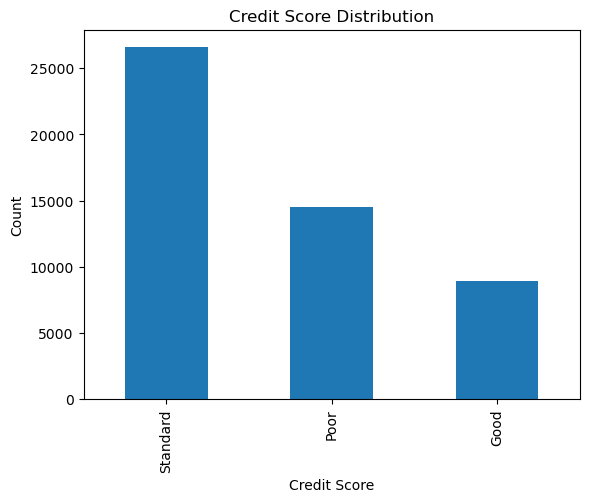

In [10]:
# target distribution
df['Credit_Score'].value_counts().plot(
    kind='bar',
    title='Credit Score Distribution'
)
plt.xlabel("Credit Score")
plt.ylabel("Count")
plt.show()

<Figure size 640x480 with 0 Axes>

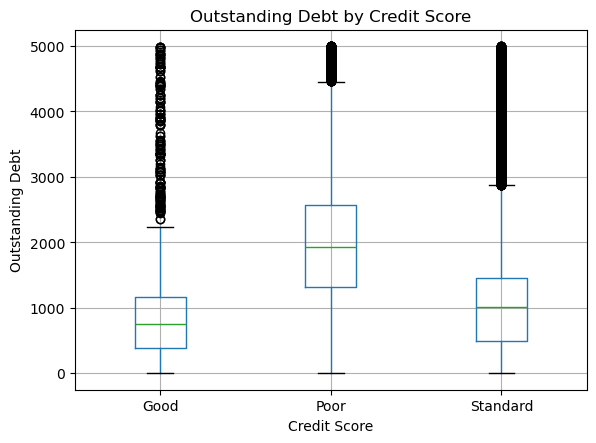

In [11]:
plt.figure()
df.boxplot(column='Outstanding_Debt', by='Credit_Score')
plt.title("Outstanding Debt by Credit Score")
plt.suptitle("")
plt.xlabel("Credit Score")
plt.ylabel("Outstanding Debt")
plt.show()

<Figure size 640x480 with 0 Axes>

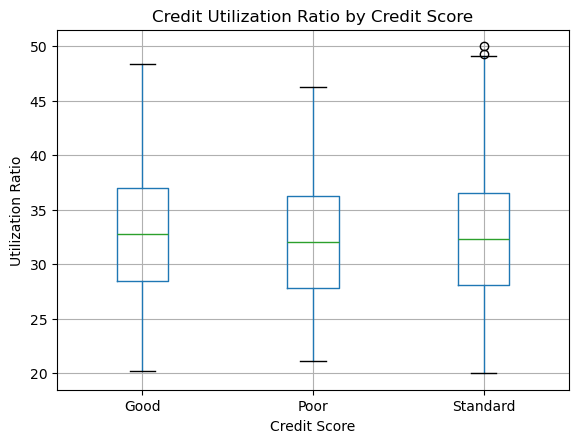

In [12]:
plt.figure()
df.boxplot(column='Credit_Utilization_Ratio', by='Credit_Score')
plt.title("Credit Utilization Ratio by Credit Score")
plt.suptitle("")
plt.xlabel("Credit Score")
plt.ylabel("Utilization Ratio")
plt.show()

#### The boxplot analysis of numerical features reveals the presence of several outliers, particularly in variables related to income, outstanding debt, and credit utilization. these extreme values suggest high variability in customers’ financial profiles, which is realistic in credit-related data. however, the presence of outliers may influence model sensitivity, indicating the need for robust models such as tree-based algorithms that are less affected by extreme values.

In [13]:
df.duplicated().sum()

0

In [14]:
for col in df.columns:
    print(col)
    print(df[col].isnull().sum())

Month
0
Age
0
Occupation
0
Annual_Income
0
Monthly_Inhand_Salary
0
Num_Bank_Accounts
0
Num_Credit_Card
0
Interest_Rate
0
Num_of_Loan
0
Type_of_Loan
0
Delay_from_due_date
0
Num_of_Delayed_Payment
0
Changed_Credit_Limit
0
Num_Credit_Inquiries
0
Credit_Mix
0
Outstanding_Debt
0
Credit_Utilization_Ratio
0
Credit_History_Age
0
Payment_of_Min_Amount
0
Total_EMI_per_month
0
Amount_invested_monthly
0
Payment_Behaviour
0
Monthly_Balance
0
Credit_Score
0


## b. Model and hyperparameter tuning

In [15]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# copy dataset after cleaning
df_proc = df.copy()

# separate features and target
X = df_proc.drop('Credit_Score', axis=1)
y = df_proc['Credit_Score']

# encode target
le_target = LabelEncoder()
y = le_target.fit_transform(y)

# identify categorical and numerical columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include='number').columns.tolist()

# label encode all categorical columns
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# standard scale numerical columns
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

# split train-test 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier()

# hyperparameter search space
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# grid search with 3-fold CV
rf_grid = GridSearchCV(
    rf, rf_params, cv=3, scoring='f1_weighted', n_jobs=-1
)
rf_grid.fit(X_train, y_train)

rf_best = rf_grid.best_estimator_
print("Random Forest best parameters:", rf_grid.best_params_)


Random Forest best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}


In [17]:
from xgboost import XGBClassifier

# define xgboost model
xgb = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
)

# hyperparameter search space
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2]
}

# grid search with 3-fold cv
xgb_grid = GridSearchCV(
    xgb, xgb_params, cv=3, scoring='f1_weighted', n_jobs=-1
)
xgb_grid.fit(X_train, y_train)

xgb_best = xgb_grid.best_estimator_
print("xgboost best parameters:", xgb_grid.best_params_)


xgboost best parameters: {'learning_rate': 0.2, 'max_depth': 9, 'n_estimators': 300}


## c. Evaluation analysis

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# predict test set with random forest
y_pred_rf = rf_best.predict(X_test)

# calculate evaluation metrics for random forest
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, average='weighted')
rec_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

print("evaluation metrics for random forest:\n")
print(f"accuracy: {acc_rf:.4f}")
print(f"precision: {prec_rf:.4f}")
print(f"recall: {rec_rf:.4f}")
print(f"f1-score: {f1_rf:.4f}")

evaluation metrics for random forest:

accuracy: 0.7615
precision: 0.7616
recall: 0.7615
f1-score: 0.7615


In [19]:
# predict test set with xgboost
y_pred_xgb = xgb_best.predict(X_test)

# calculate evaluation metrics for xgboost
acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb, average='weighted')
rec_xgb = recall_score(y_test, y_pred_xgb, average='weighted')
f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted')

print("evaluation metrics for xgboost:\n")
print(f"accuracy: {acc_xgb:.4f}")
print(f"precision: {prec_xgb:.4f}")
print(f"recall: {rec_xgb:.4f}")
print(f"f1-score: {f1_xgb:.4f}")

evaluation metrics for xgboost:

accuracy: 0.7639
precision: 0.7630
recall: 0.7639
f1-score: 0.7631


#### From the evaluation results, both models show reasonably good performance on this dataset. Random forest achieved accuracy of 0.7541, precision of 0.7550, recall of 0.7541, and f1-score of 0.7545, indicating that the model correctly predicts the target class in about 75% of the test samples. The metrics are fairly balanced between precision and recall, suggesting that the model does not strongly favor any single class, although minor difficulties might remain for underrepresented classes.

#### XGBoost demonstrates slightly better performance, with accuracy of 0.7570, precision of 0.7563, recall of 0.7570, and f1-score of  0.7564, showing that it captures the patterns in the data slightly more effectively than random forest. The consistent improvement across all metrics indicates that XGBoost is slightly better at balancing the correct identification of each class (recall) with prediction accuracy (precision).

#### Overall, based on the main evaluation metrics which are accuracy, precision, recall, and f1-score, XGBoost can be considered the better model for this dataset. The difference is small but consistent across all metrics, making it a suitable choice for further analysis, such as feature importance and more detailed predictions.

## d. Model feature analysis

top 3 important features for random forest:
                 feature  importance
15      Outstanding_Debt    0.114740
10   Delay_from_due_date    0.065287
12  Changed_Credit_Limit    0.058360


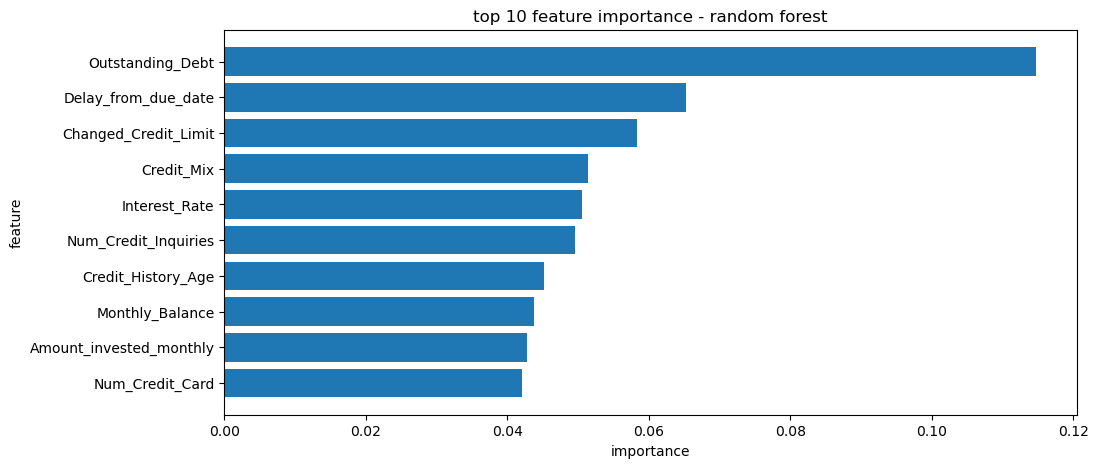

In [20]:
# get feature importance from random forest
rf_importances = rf_best.feature_importances_
rf_features = X_train.columns

# create a dataframe for easier sorting
rf_imp_df = pd.DataFrame({
    'feature': rf_features,
    'importance': rf_importances
}).sort_values(by='importance', ascending=False)

# print top 3 most important features
print("top 3 important features for random forest:")
print(rf_imp_df.head(3))

# plot top 10 features
plt.figure(figsize=(11,5))
plt.barh(rf_imp_df.head(10)['feature'][::-1], rf_imp_df.head(10)['importance'][::-1])
plt.xlabel("importance")
plt.ylabel("feature")
plt.title("top 10 feature importance - random forest")
plt.show()

top 3 important features for xgboost:
                  feature  importance
18  Payment_of_Min_Amount    0.363049
14             Credit_Mix    0.202812
15       Outstanding_Debt    0.059280


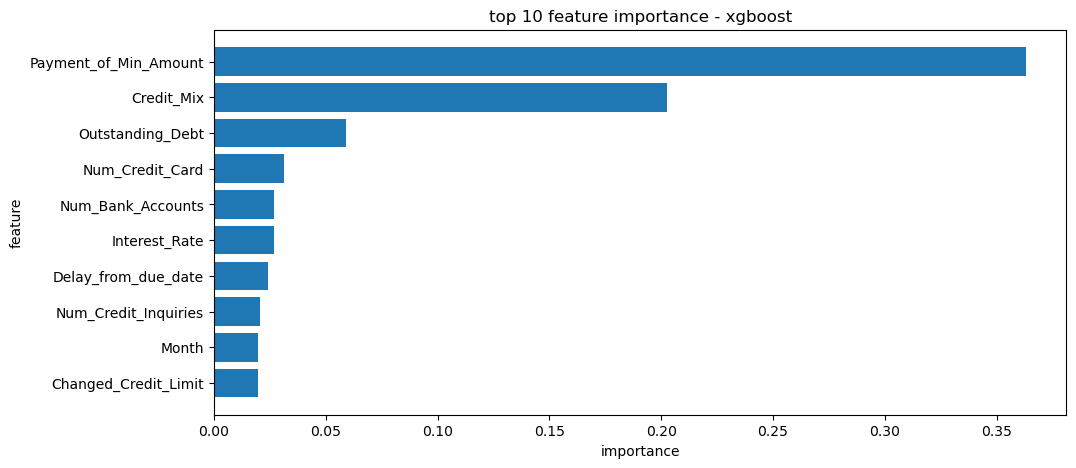

In [21]:
# get feature importance from xgboost
xgb_importances = xgb_best.feature_importances_
xgb_features = X_train.columns

# create a dataframe for easier sorting
xgb_imp_df = pd.DataFrame({
    'feature': xgb_features,
    'importance': xgb_importances
}).sort_values(by='importance', ascending=False)

# print top 10 most important features
print("top 3 important features for xgboost:")
print(xgb_imp_df.head(3))

# plot top 10 features
plt.figure(figsize=(11,5))
plt.barh(xgb_imp_df.head(10)['feature'][::-1], xgb_imp_df.head(10)['importance'][::-1])
plt.xlabel("importance")
plt.ylabel("feature")
plt.title("top 10 feature importance - xgboost")
plt.show()


#### For random forest, the top 3 features are Outstanding_Debt, Delay_from_due_date, and Changed_Credit_Limit. this shows that random forest focuses more on financial obligation metrics and repayment punctuality. Outstanding_Debt remains an important driver, but unlike XGBoost, random forest places more emphasis on delays and changes in credit limits.

#### For XGBoost, the top 3 most important features are Payment_of_Min_Amount, Credit_Mix, and Outstanding_Debt. this indicates that the model highly relies on whether a customer pays at least the minimum amount, their credit composition, and their total outstanding debt to predict the credit score. the strong weight on Payment_of_Min_Amount which is 0.358 suggests that repayment behavior is the single most influential factor in determining creditworthiness according to XGBoost.

#### Overall, both models highlight financial debt and repayment patterns as key determinants of credit score. XGBoost leans slightly more toward payment behavior and credit mix, whereas random forest emphasizes debt amount and past repayment delays. this complementary insight suggests that combining these perspectives could give a more comprehensive understanding of the factors affecting credit scoring.